In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,train_test_split,cross_val_predict,cross_val_score
from sklearn.metrics import r2_score,mean_absolute_error,mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression,Ridge,Lasso

In [29]:
df=pd.read_excel('data/premiums.xlsx')
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [8]:
df.shape

(49976, 13)

In [3]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='str')

In [30]:
df.columns=df.columns.str.replace(' ','_').str.lower()
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='str')

In [4]:
df.dtypes

Age                      int64
Gender                     str
Region                     str
Marital_status             str
Number Of Dependants     int64
BMI_Category               str
Smoking_Status             str
Employment_Status          str
Income_Level               str
Income_Lakhs             int64
Medical History            str
Insurance_Plan             str
Annual_Premium_Amount    int64
dtype: object

# handel null values

In [6]:
df.isnull().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [31]:
df.dropna(inplace=True)# droping every null value

In [32]:
df.duplicated().sum()# finding duplicate values
# df.drop_duplicates(inplace=True)

np.int64(0)

In [11]:
round(df.describe(),2)

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.00,49976.00,49976.00,49976.00
mean,34.59,1.71,23.02,15766.81
std,15.00,1.50,24.22,8420.00
min,18.00,-3.00,1.00,3501.00
25%,22.00,0.00,7.00,8607.75
50%,31.00,2.00,17.00,13928.00
75%,45.00,3.00,31.00,22273.50
max,356.00,5.00,930.00,43471.00


In [13]:
df[df.number_of_dependants<0].shape

(72, 13)

## number_of_dependants column tranformation

In [ ]:
df[df.number_of_dependants<0]['number_of_dependants'].unique() # ask your data engineer about those negative values, he said they are positive values but while collecting data some mistake happened,so convert those negative values to positive

array([-3, -1])

In [34]:
df['number_of_dependants']=abs(df['number_of_dependants'])# converting negative values to positive
df[df.number_of_dependants<0]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount


In [35]:
df.number_of_dependants.describe()

count    49976.000000
mean         1.717284
std          1.491953
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

In [38]:
df.select_dtypes(['float64','int64'])# getting numarical values

,age,number_of_dependants,income_lakhs,annual_premium_amount
0,26,0,6,9053
1,29,2,6,16339
2,49,2,20,18164
3,30,3,77,20303
4,18,0,99,13365
...,...,...,...,...
49995,24,0,35,9111
49996,47,2,82,27076
49997,21,0,32,8564
49998,18,2,20,9490


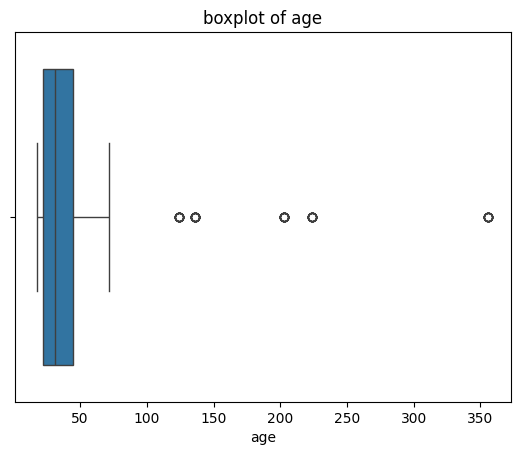

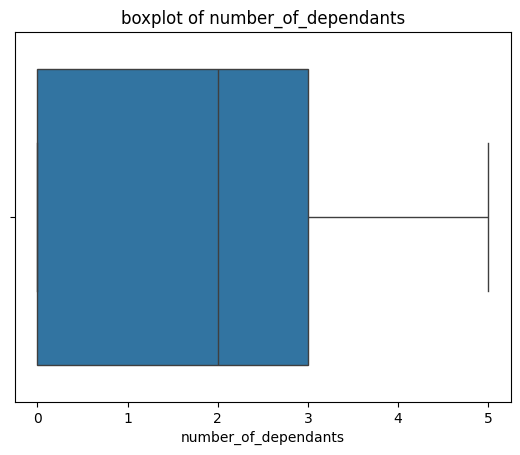

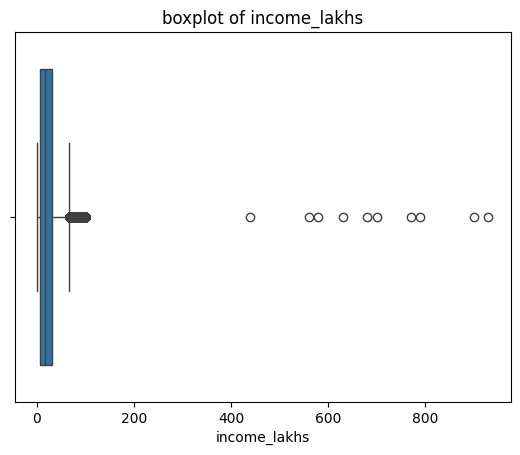

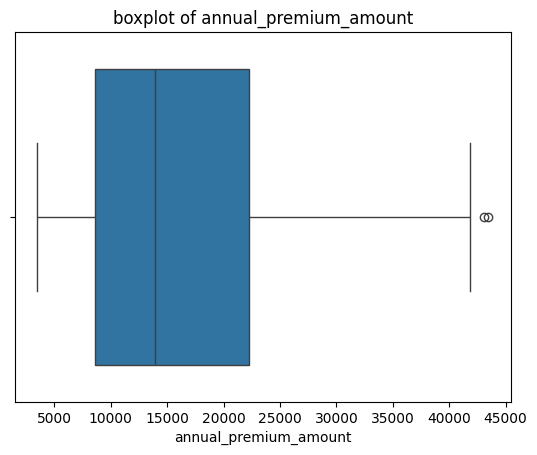

In [43]:
box =['age', 'number_of_dependants', 'income_lakhs',
       'annual_premium_amount']
for col in box:
    sns.boxplot(x=df[col])
    plt.title(f'boxplot of {col}')
    plt.show()

In [40]:
df[df['age']>100]['age'].unique()

array([224, 124, 136, 203, 356])

In [41]:
df1=df[df['age']<=100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.717617,23.025141,15766.589286
std,13.681600,1.492074,24.227912,8419.137327
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


<Axes: xlabel='income_lakhs', ylabel='Count'>

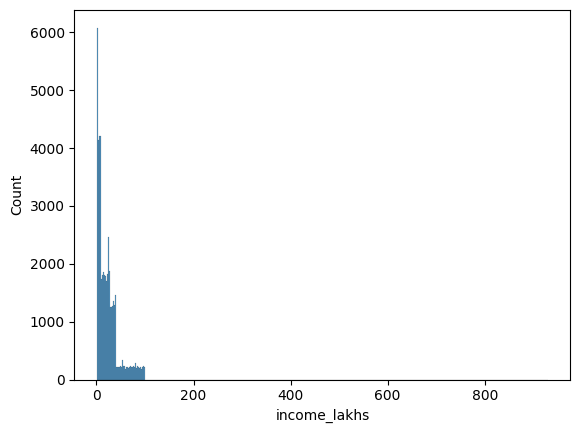

In [42]:
sns.histplot(df1['income_lakhs'])

In [44]:
def get_iqr(col):
    q1,q3=col.quantile([.25,.75])
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr
    return lower_bound,upper_bound

In [45]:
get_iqr(df1['income_lakhs'])

(-29.0, 67.0)

In [47]:
quantile_thresold=df1['income_lakhs'].quantile(0.999)
quantile_thresold

np.float64(100.0)

In [48]:
df1[df1['income_lakhs']>quantile_thresold]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
2635,51,Male,Northwest,Married,4,Obesity,No Smoking,Self-Employed,> 40L,560,High blood pressure,Gold,30692
4220,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,440,No Disease,Silver,10636
7775,35,Female,Northeast,Unmarried,0,Overweight,No Smoking,Salaried,> 40L,630,Diabetes,Gold,24010
9021,43,Male,Southeast,Married,3,Obesity,Regular,Salaried,> 40L,900,Diabetes & Thyroid,Gold,30848
10337,37,Female,Southeast,Married,3,Normal,No Smoking,Freelancer,> 40L,930,Diabetes,Silver,15945
10639,20,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,580,Thyroid,Silver,12888
11456,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424
15437,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586
35446,59,Male,Northwest,Married,2,Obesity,Occasional,Self-Employed,> 40L,770,Thyroid,Gold,31115
40970,48,Male,Northeast,Married,4,Obesity,No Smoking,Salaried,> 40L,680,No Disease,Gold,28926


In [51]:
df1[df1['income_lakhs']>quantile_thresold].shape

(10, 13)

In [53]:
df2=df1[df1.income_lakhs<=quantile_thresold].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,22.889897,15765.739641
std,13.681604,1.492032,22.170699,8418.674061
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22270.500000
max,72.000000,5.000000,100.000000,43471.000000
